In [1]:
import torch.utils.data as data
from torch_geometric.loader import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import uproot
import numpy as np
import torch_geometric
import torch_cluster

from torch_geometric.data import Data
import torch
import awkward as ak
import numpy

import torch.nn as nn
from torch.nn import Linear, Parameter
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import add_self_loops, degree, scatter, index_to_mask
import torch.nn.functional as F

from torchvision import transforms
import matplotlib.pyplot as plt

#Device Agnostic code
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

f_h = "/home/sawini-jana/hep/MG5_aMC_v3_7_1/dihiggs_output_13TeV.root"
f_qcd = "/home/sawini-jana/hep/MG5_aMC_v3_7_1/qcd_output_13TeV.root"

In [19]:
needed = ["Particle.PID","FatJet.Particles"]
file = uproot.open(f_h)
tree = file["Delphes"]
branch = tree.arrays(needed)
L = []
for idx in range(len(branch)):
    refs = branch["FatJet.Particles"][idx, 0].refs - 1
    part_pid = ak.to_numpy(branch["Particle.PID"][idx][refs])
    unique_pid = np.unique(part_pid).tolist()
    L.extend(unique_pid)


In [3]:
class Jet_Dataset(data.Dataset):

    def __init__(self, filepath, k = 7, label = 0):
        super().__init__()
        self.file = uproot.open(filepath)
        self.tree = self.file["Delphes"] #awkward high-level object
        
        needed = ["FatJet.PT","FatJet.Eta","FatJet.Mass","FatJet.Tau[5]","FatJet.SoftDroppedP4[5]","FatJet.Particles", "FatJet.Phi",
            "Particle.PT","Particle.Eta","Particle.Phi","Particle.Px","Particle.Py","Particle.Pz","Particle.E","Particle.Mass","Particle.Charge","Particle.PID",
        ]
        self.branch = self.tree.arrays(needed)
        self.num_entries = len(self.branch)
        self.label = label
        self.k = k

        self.unique_pid = [-2212, -2112, -321, -211, -13, -11, 11, 13, 22, 130, 211, 321, 2112, 2212]
        self.pid_map = {pid: i for i, pid in enumerate(self.unique_pid)}
        #no empty ones to be passed
        self.valid_idx = []
        for i in range(self.num_entries):
            if len(self.branch["FatJet.PT"][i]) == 0:
                continue
            if len(self.branch["FatJet.SoftDroppedP4[5]"][i]) == 0:
                continue

            self.valid_idx.append(i)

    def pt_cloud(self, idx):
        #jet, label, part, aux
        if len(self.branch["FatJet.PT"][idx]) == 0:
            raise IndexError(f"Event {idx} contains no FatJet.")
        
        #JET
        fat_pt   = np.array([self.branch["FatJet.PT"][idx][0]], dtype=np.float32)/1000
        fat_eta  = np.array([self.branch["FatJet.Eta"][idx][0]], dtype=np.float32)
        fat_mass = np.array([self.branch["FatJet.Mass"][idx][0]], dtype=np.float32)/200
        #-----------Soft Drop Energy and mass--------------
        sd = self.branch["FatJet.SoftDroppedP4[5]"][idx][0][0]
        sd_energy = np.array([sd.fE], dtype=np.float32)/1000
        
        m2 = (sd.fE**2- sd.fP.fX**2- sd.fP.fY**2- sd.fP.fZ**2)
        sd_mass = np.array([np.sqrt(max(m2, 0.0))], dtype=np.float32)/200
        # ---------- tau_21 ----------
        tau = self.branch["FatJet.Tau[5]"][idx][0]
        tau1 = np.array([tau[0]], dtype=np.float32)
        tau2 = np.array([tau[1]], dtype=np.float32)
        tau21 = np.full_like(tau1, -1.0)
        np.divide(tau2, tau1, out=tau21, where=tau1 > 0)
        jet_feat = np.stack([fat_pt,fat_eta,fat_mass,sd_energy,sd_mass,tau21],axis=1)
        
        #part
        refs = self.branch["FatJet.Particles"][idx, 0].refs - 1

        part_pt     = ak.to_numpy(self.branch["Particle.PT"][idx][refs])
        part_eta    = ak.to_numpy(self.branch["Particle.Eta"][idx][refs])
        part_phi    = ak.to_numpy(self.branch["Particle.Phi"][idx][refs])
        part_px     = ak.to_numpy(self.branch["Particle.Px"][idx][refs])
        part_py     = ak.to_numpy(self.branch["Particle.Py"][idx][refs])
        part_pz     = ak.to_numpy(self.branch["Particle.Pz"][idx][refs])
        part_energy = ak.to_numpy(self.branch["Particle.E"][idx][refs])
        part_mass   = ak.to_numpy(self.branch["Particle.Mass"][idx][refs])
        part_charge = ak.to_numpy(self.branch["Particle.Charge"][idx][refs])
        part_pid    = ak.to_numpy(self.branch["Particle.PID"][idx][refs])    
        part_pid    = torch.tensor([self.pid_map[p] for p in part_pid],dtype=torch.long)
    
        pt_frac = part_pt / (fat_pt.item() + 1e-8)
    
        part_eta = (part_eta - part_eta.mean()) / (part_eta.std() + 1e-8)
        part_px = (part_px - part_px.mean()) / (part_px.std() + 1e-8)
        part_py = (part_py - part_py.mean()) / (part_py.std() + 1e-8)
        part_pz = (part_pz - part_pz.mean()) / (part_pz.std() + 1e-8)
        part_energy = (part_energy - part_energy.mean()) / (part_energy.std() + 1e-8)
        
        part_feat = torch.tensor(np.stack([pt_frac,part_px, part_py, part_pz,part_eta,part_energy,part_mass,part_charge],axis=1),dtype=torch.float32)
        
        #concantenate part and jet together (x)
        n_particles = len(part_pt)
        jet_feat = np.repeat(jet_feat, n_particles, axis=0)
        con = torch.cat((torch.tensor(jet_feat, dtype=torch.float32),part_feat),dim=1)
        con[torch.isnan(con)] = 0.0

        #edge_index
        graph_pos = torch.tensor(
            np.stack([
                part_eta,
                part_phi,
                np.log(part_pt + 1e-8)
            ], axis=1),
            dtype=torch.float32)
        
        edge_index = torch_geometric.nn.pool.knn_graph(x=graph_pos,k=self.k)
        
        #edge_attributes
        src, dst = edge_index[0].cpu().numpy(),edge_index[1].cpu().numpy() 
        delta_eta = part_eta[src] - part_eta[dst]
        delta_phi = part_phi[src] - part_phi[dst]
        
        delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi
        delta_R = np.sqrt(delta_eta**2 + delta_phi**2)
        # log(pt_i / pt_j)
        log_pt_ratio = np.log((part_pt[src] + 1e-8) /(part_pt[dst] + 1e-8))
        # z_ij = min(pt_i, pt_j)/(pt_i + pt_j)
        zij = np.minimum(part_pt[src], part_pt[dst]) / (part_pt[src] + part_pt[dst] + 1e-8)
           # invariant mass of particle pair
        E  = part_energy[src] + part_energy[dst]
        Px = part_px[src] + part_px[dst]
        Py = part_py[src] + part_py[dst]
        Pz = part_pz[src] + part_pz[dst]

        m2 = E**2 - Px**2 - Py**2 - Pz**2
        mij = np.sqrt(np.maximum(m2, 0.0))
     
        edge_deltaR = torch.tensor(np.stack([delta_eta,delta_phi,delta_R,log_pt_ratio,zij,mij], axis=1),dtype=torch.float32)

        #Data
        data = Data(x=con,edge_index=edge_index,edge_attr=edge_deltaR)
        data.label = torch.tensor(self.label, dtype=torch.long)
        data.sd_mass = torch.tensor(sd_mass.item(), dtype=torch.float32)
        data.seq_length = torch.tensor(n_particles, dtype=torch.long)
        data.pid = part_pid
        data.pos = torch.tensor(np.stack([part_eta, part_phi], axis=1),dtype=torch.float32)
        
        return data

    def __len__(self):
        return len(self.valid_idx)
    
    def __getitem__(self, index):
        return self.pt_cloud(self.valid_idx[index])

#In general, Embedding dimension is the number of features each node has after embedding
#or Message Passing .. of the shape [num_nodes, emb_dim]
#predict sd_mass as well as class labels 

#Edge Dimension is the number of features each edge carries, 
#in the shape of edge_attr... [num_edges, edge_dim]

jet_dataset_h = Jet_Dataset(f_h, label = 1)
jet_dataset_qcd = Jet_Dataset(f_qcd, label = 0)


In [4]:
from torch.utils.data import ConcatDataset
dataset = ConcatDataset([jet_dataset_h, jet_dataset_qcd])

#Creating training and testing datasets
batch_size = 32
test_size = 0.2
indices = list(range(len(dataset)))
np.random.shuffle(indices)
split = int(np.floor(test_size * len(dataset)))
test_index, valid_index, train_index,   = indices[:split], indices[split:split*2], indices[split*2:]


# define samplers for obtaining training and testing batches
train_sampler = SubsetRandomSampler(train_index)
test_sampler = SubsetRandomSampler(test_index)
valid_sampler = SubsetRandomSampler(valid_index)
train_load = DataLoader(dataset, batch_size = batch_size, sampler = train_sampler)
test_load = DataLoader(dataset, batch_size = batch_size, sampler = test_sampler)
valid_loader = DataLoader(dataset, batch_size = batch_size, sampler = valid_sampler)


In [5]:
class GCNConv(MessagePassing):

    def __init__(self, in_channels, out_channels):
        super().__init__(aggr="add")
        self.lin = Linear(in_channels, out_channels, bias =False)
        self.bias = Parameter(torch.empty(out_channels))

        self.reset_parameters()

    def reset_parameters(self):
        self.lin.reset_parameters()
        self.bias.data.zero_()

    def forward(self, x, edge_index, batch):
        #x --> [N, in_channels]
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0)) #2,E

        x = self.lin(x) # x --> [N, out_channels]

        source, target = edge_index #[E]
        #print(f"HI: {len(target)}")
        deg = degree(target, x.size(0), dtype=x.dtype) #[N]
        deg_inv_sqrt = deg.pow(-0.5) #[N]
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[source] * deg_inv_sqrt[target] #[E]
        #print(f"HI: {norm.shape}")
        out = self.propagate(edge_index, x=x, norm=norm)
        #[N, out_channels]
        #but why change from E to N?

        out = out + self.bias

        return out

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j
           #*[E,1] x [E, out_channels] = [E, out_channels] 

class GCNModule(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.pid_embedding = nn.Embedding(14, 8)
        self.input_proj = nn.Sequential(nn.Linear(in_dim+8, hidden_dim),nn.BatchNorm1d(hidden_dim),nn.ReLU())
        self.conv1 = GCNConv( hidden_dim , hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, out_dim)
      
    def forward(self, x, edge_index, pid, batch):
        #print("x:", x.shape)
        pid_feat = self.pid_embedding(pid)
        x = torch.cat([x, pid_feat], dim = 1)
        x = self.input_proj(x)
        x = self.conv1(x, edge_index, batch)
        #print("After conv1:", x.shape)
        x = F.relu(x)
        x = self.conv2(x, edge_index, batch)
        #print("After conv2:", x.shape)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        #print("After global mean pool:", x.shape)
        
        return self.lin(x)

model = GCNModule(in_dim= len(dataset[0].x[0]),hidden_dim = 64, out_dim = 2).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr = 3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,factor=0.5,patience=5)
loss = nn.CrossEntropyLoss()

In [6]:
from tqdm import tqdm
from tqdm import trange

In [7]:
print(dataset[0].x.shape)

torch.Size([31, 14])


Processing:   7%|▋         | 1/15 [03:13<45:08, 193.50s/it]

Epoch 0 | Train Loss: 0.5315986033132736 | Test Loss: 0.5500534946918487


Processing:  13%|█▎        | 2/15 [06:50<44:51, 207.06s/it]

Epoch 1 | Train Loss: 0.46392368358817504 | Test Loss: 0.42151986014842985


Processing:  20%|██        | 3/15 [09:25<36:42, 183.52s/it]

...

Epoch 12 | Train Loss: 0.40753389375799515 | Test Loss: 0.39409240329265594


Processing:  93%|█████████▎| 14/15 [23:49<01:10, 70.84s/it]

Epoch 13 | Train Loss: 0.40314665048363363 | Test Loss: 0.40617381227016447


Processing: 100%|██████████| 15/15 [24:58<00:00, 99.93s/it]

Epoch 14 | Train Loss: 0.4071764581777314 | Test Loss: 0.39083238518238067
Best for test Loss: inf


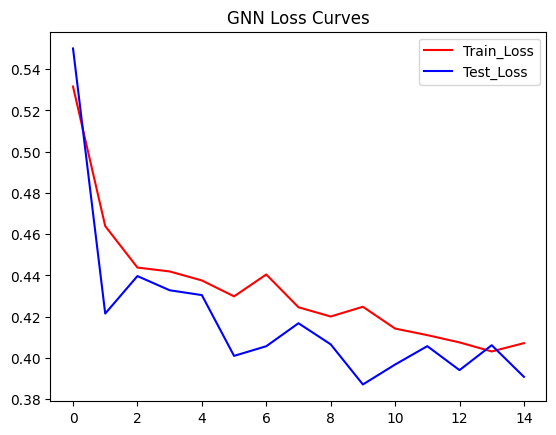

In [8]:

#training model
def train(train_loader, model, optimizer, loss_fn):
    model.train()
    train_loss = 0

    for data in tqdm(train_loader, desc="Training batches"):
        data = data.to(device)
        #print(f"MYDATA: {data}")
        y_pred = model(data.x, data.edge_index, data.pid, data.batch)
        #print(y_pred.dtype, label.dtype)
        
        loss = loss_fn(y_pred, data.label)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

    train_loss /= len(train_loader)
    return train_loss

def test(test_loader, model, loss_fn):
    model.eval()
    test_loss = 0

    with torch.inference_mode():
        for data in test_loader:

            data = data.to(device)

            test_pred = model(data.x, data.edge_index, data.pid, data.batch)
            
            #print("TEST_PRED:",test_pred)
            loss = loss_fn(test_pred, data.label)
            #print("Data_label:", data.label )
            test_loss += loss.item()

    test_loss /= len(test_loader)

    return test_loss


ep = []
result1 = []
result2 = []
min = torch.inf


import numpy as np
for epoch in trange (15, desc="Processing"):
    train_loss = train(train_load, model, optimizer, loss)
    test_loss = test( test_load,model, loss)
    ep.append(epoch)
    result1.append(np.array(torch.tensor(train_loss).numpy()))
    result2.append(np.array(torch.tensor(test_loss).numpy()))

    #draw_epoch_graph(G, model_1.latest)
    print(f"Epoch {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}")

    best_loss = float("inf")
    patience = 10
    counter = 0
    
    if test_loss < best_loss:

        best_loss = test_loss
        counter = 0
        torch.save({
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
            }, "checkpoint.pt")
    else:
        counter += 1
    
    if counter==patience:
        print("Stopping")
        break
    
    scheduler.step(test_loss)

print(f"Best for test Loss: {min}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("GNN Loss Curves")
plt.show()


In [10]:

def eval_model(model,valid_loader ):
    model.eval()
    true_preds = num_preds = 0

    with torch.inference_mode():
        for data in valid_loader:
            data = data.to(device)
            Valid_pred = model(data.x, data.edge_index, data.pid, data.batch)
            
            pred_labels = torch.argmax(Valid_pred, dim= 1)
            
            true_preds += (pred_labels == data.label).sum()

            num_preds += len(data.label)
    
    acc2 = true_preds/num_preds
    print(f"Accuracy of the model: {100.0*acc2}%")

model_test = GCNModule(in_dim= len(dataset[0].x[0]),hidden_dim = 64, out_dim = 2)
checkpoint = torch.load("checkpoint.pt", map_location=device)
model_test.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])
scheduler.load_state_dict(checkpoint["scheduler"])
eval_model(model_test, valid_loader)


Accuracy of the model: 81.89547729492188%


In [11]:
print(f"Best for test Loss: {best_loss}")

Best for test Loss: 0.39083238518238067


In [12]:
class MPNNLayer(MessagePassing):
    def __init__(self, emb_dim , hidden_layers , edge_dim, aggr='add'):   #(64, 32, 1)
        super().__init__(aggr=aggr)

        self.emb_dim = emb_dim      #64
        self.edge_dim = edge_dim    #1

        self.mlp_msg = nn.Sequential(
            Linear(2 * emb_dim + edge_dim, hidden_layers), nn.BatchNorm1d(hidden_layers), nn.ReLU(),nn.Dropout(0.5),
            Linear(hidden_layers, emb_dim), nn.ReLU(),nn.Dropout(0.5), nn.BatchNorm1d(emb_dim)
        )    #(E, 64)

        self.upd_msg = nn.Sequential(
            Linear(emb_dim * 2, hidden_layers), nn.BatchNorm1d(hidden_layers), nn.ReLU(),
            Linear(hidden_layers, emb_dim), nn.ReLU(), nn.BatchNorm1d(emb_dim)
        )   #(N, 64)

    def forward(self, x, edge_index, edge_attr):
        self.x = x  #[N,25]
        return self.propagate(edge_index=edge_index, x=x, edge_attr=edge_attr)

        #x_i contains the features of the target nodes for each edge
        #x_j contains the features of the source nodes for each edge
    def message(self, x_i, x_j, edge_attr):
        msg_input = torch.cat([x_i, x_j, edge_attr], dim=1)     #(E, 3)
        return self.mlp_msg(msg_input)                          #(E, 64)

        #inputs = the output of message
        #index is x_i
    def aggregate(self, inputs, index):
        return scatter(inputs, index, dim=0, reduce=self.aggr)  #(N, 64)

        #aggr_out is the output of aggregate (N,64)
        #x is original node features (N, 64)
    def update(self, aggr_out, x):
        upd_input = torch.cat([x, aggr_out], dim=1)
        #print(upd_input.shape)
        return self.upd_msg(upd_input) #(N, 64)

class MPNNModel(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden_dim=64, num_layers=3): #(25,1)
        super().__init__()

        self.pid_embedding = nn.Embedding(14, 8)
        #1.
        self.lin_in = nn.Sequential(Linear(in_dim + 8, hidden_dim),nn.BatchNorm1d(hidden_dim),nn.ReLU())#x --> (N, 64) 
        #2. layers of calling
        self.convs = nn.ModuleList()
        for layer in range(num_layers):
            self.convs.append(MPNNLayer(emb_dim = hidden_dim ,hidden_layers =64, edge_dim = edge_dim))
                                        # emb_dim = 64                              edge_dim = 1                 
        #3.Pooling
        self.pool = global_mean_pool #[1,64]

        
        #4. Linear
        self.lin_layer = nn.Linear(in_features=hidden_dim,
                                   out_features= 2)

    
    def forward(self, data):
        x, edge_index, edge_attr,pid, batch = data.x, data.edge_index, data.edge_attr, data.pid, data.batch
        pid_feat = self.pid_embedding(pid)
        x = torch.cat([data.x, pid_feat], dim=1)
        x =self.lin_in(x) #(N, 64)
        #print("BEFORE CONV: ", x.shape)
        for conv in self.convs:
            x = x + conv(x, edge_index, edge_attr)
        #[N, 64]
        x = F.layer_norm(x, x.shape[-1:]) #just normalizing over the last dimension, that is normalizinf of each row
        #print("AFTER CONV: ",x.shape)
        x = self.pool(x, batch) #[batch, 1, 64]
        #print("AFTER POOL", x.shape)
        return self.lin_layer(x) #[batch, 1, 3]

model_MPNN = MPNNModel(in_dim= len(dataset[0].x[0]), edge_dim=len(dataset[0].edge_attr[0])).to(device)
#(25,1)

optimizer_MPNN = torch.optim.Adam(model_MPNN.parameters(), lr = 1e-3, weight_decay=1e-4)
scheduler_MPNN = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_MPNN,mode="min",factor=0.5,patience=5)

Processing:   3%|▎         | 1/30 [02:03<59:40, 123.46s/it]

Epoch 0 | Train Loss: 0.5186888973446603 | Test Loss: 0.4692986762523651


Processing:   7%|▋         | 2/30 [04:08<58:10, 124.67s/it]

Epoch 1 | Train Loss: 0.46978907100856304 | Test Loss: 0.4264071727991104


Processing:  10%|█         | 3/30 [06:15<56:32, 125.63s/it]

...

Epoch 27 | Train Loss: 0.36335247430078527 | Test Loss: 0.3569771853685379


Processing:  97%|█████████▋| 29/30 [58:12<02:07, 127.95s/it]

Epoch 28 | Train Loss: 0.3612115314190692 | Test Loss: 0.37369144344329835


Processing: 100%|██████████| 30/30 [1:01:49<00:00, 123.64s/it]

Epoch 29 | Train Loss: 0.3652945112714425 | Test Loss: 0.3821212725639343
Best for test Loss: 0.3569771853685379


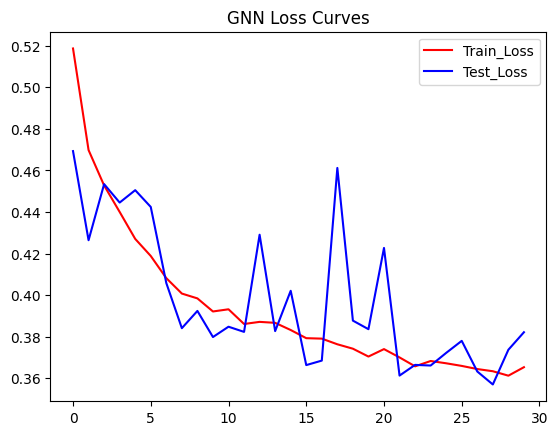

In [ ]:
#training model
def train(train_loader, model, optimizer, loss_fn):
    model.train()
    train_loss = 0

    for data in tqdm(train_loader, desc="Training batches"):
        data = data.to(device)
        #print(f"MYDATA: {data}")
        y_pred = model(data)
        #print(y_pred.dtype, label.dtype)
        #[batch, 1, 3] #[batch, 1]
        loss = loss_fn(y_pred, data.label)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

    train_loss /= len(train_loader)
    return train_loss

def test(test_loader, model, loss_fn):
    model.eval()
    test_loss = 0

    with torch.inference_mode():
        for data in test_loader:

            data = data.to(device)

            test_pred = model(data)
            
            #print("TEST_PRED:",test_pred) 
            loss = loss_fn(test_pred, data.label)
            #print("Data_label:", data.label )
            test_loss += loss.item()

    test_loss /= len(test_loader)

    return test_loss
ep = []
result1 = []
result2 = []
best_loss = torch.inf
patience = 10
counter = 0

import numpy as np
for epoch in trange (30, desc="Processing"):
    train_loss = train(train_load, model_MPNN, optimizer_MPNN, loss)
    test_loss = test( test_load,model_MPNN, loss)
    ep.append(epoch)
    result1.append(np.array(torch.tensor(train_loss).numpy()))
    result2.append(np.array(torch.tensor(test_loss).numpy()))

    #draw_epoch_graph(G, model_1.latest)
    print(f"Epoch {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}")
    
    if test_loss < best_loss:

        best_loss = test_loss
        counter = 0
        torch.save({
                "model": model_MPNN.state_dict(),
                "optimizer": optimizer_MPNN.state_dict(),
                "scheduler": scheduler_MPNN.state_dict(),
            }, "checkpoint.pt")
    else:
        counter += 1
    
    if counter==patience:
        print("Stopping")
        break
    
    scheduler_MPNN.step(test_loss)

print(f"Best for test Loss: {best_loss}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("GNN Loss Curves")
plt.show()

In [14]:

def eval_model(model,valid_loader ):
    model.eval()
    true_preds = num_preds = 0

    with torch.inference_mode():
        for data in valid_loader:
            data = data.to(device)
            Valid_pred = model(data)
            
            pred_labels = torch.argmax(Valid_pred, dim= 1)
            
            true_preds += (pred_labels == data.label).sum()

            num_preds += len(data.label)
    
    acc2 = true_preds/num_preds
    print(f"Accuracy of the model: {100.0*acc2}%")

model_test = MPNNModel(in_dim= len(dataset[0].x[0]), edge_dim=len(dataset[0].edge_attr[0]))
checkpoint = torch.load("checkpoint.pt", map_location=device)
model_test.load_state_dict(checkpoint["model"])
optimizer_MPNN.load_state_dict(checkpoint["optimizer"])
scheduler_MPNN.load_state_dict(checkpoint["scheduler"])
eval_model(model_test, valid_loader)


Accuracy of the model: 84.22105407714844%


In [14]:

class EdgeConv(MessagePassing):
    """DGCNN EdgeConv:  x_i' = mean_j  MLP( [ x_i , x_j - x_i ] )."""
    def __init__(self, in_channels, out_channels, aggr="mean"):
        super().__init__(aggr=aggr)
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_channels, out_channels), nn.BatchNorm1d(out_channels), nn.ReLU(),
            nn.Linear(out_channels, out_channels),    nn.BatchNorm1d(out_channels), nn.ReLU(),
        )
    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)          # gathers neighbours, calls message(), aggregates
    def message(self, x_i, x_j):                         # x_i = centre, x_j = neighbour (per edge)
        return self.mlp(torch.cat([x_i, x_j - x_i], dim=-1))
    

class EdgeConvBlock(nn.Module):
    """ParticleNet-style block: EdgeConv on a given graph + linear residual shortcut, then ReLU."""
    def __init__(self, in_channels, out_channels, aggr="mean"):
        super().__init__()
        
        self.conv = EdgeConv(in_channels, out_channels)
        self.shortcut = nn.Linear(in_channels, out_channels)
        self.act = nn.ReLU()

    def forward(self, x, edge_index):
        return self.act(self.conv(x, edge_index) + self.shortcut(x))
    
class ParticleNet(nn.Module):
    def __init__(self, in_feat, n_classes=2, k=8, conv_channels=(32, 64, 64), fc=128, dropout=0.1):
        super().__init__()
        self.k = k
        chans = [in_feat, *conv_channels] #in feat, 32, 64, 64
        self.pid_embedding = nn.Embedding(14, 8)
        self.input = nn.Sequential(nn.Linear(in_feat + 8 ,chans[1]),nn.BatchNorm1d(chans[1]),nn.ReLU())
        self.blocks = nn.ModuleList([EdgeConvBlock(chans[i], chans[i + 1])
                                     for i in range(1 ,len(conv_channels))])
        self.head = nn.Sequential(nn.Linear(conv_channels[-1], fc), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(fc, n_classes))

    def forward(self, data):
        pid = self.pid_embedding(data.pid)
        batch = data.batch if getattr(data, "batch", None) is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        feats, coords = torch.cat([data.x, pid], dim=1), data.pos
        feats = self.input(feats)

        for b, block in enumerate(self.blocks):
            edge_index = torch_geometric.nn.pool.knn_graph(coords,k=self.k, batch=batch)
            feats = block(feats, edge_index)
            coords = feats                                         # dynamic graph: next kNN uses learned feats
        return self.head(global_mean_pool(feats, batch))

model_PN = ParticleNet(in_feat= len(dataset[0].x[0])).to(device)
#(25,1)

optimizer_PN = torch.optim.Adam(model_PN.parameters(), lr = 1e-3, weight_decay=1e-4)
scheduler_PN = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_PN,mode="min",factor=0.5,patience=5)

In [15]:
print(type(dataset[0].pid))

<class 'torch.Tensor'>


Processing:   3%|▎         | 1/30 [01:23<40:12, 83.19s/it]

Epoch 0 | Train Loss: 0.5087352960192143 | Test Loss: 0.539065684556961


Processing:   7%|▋         | 2/30 [02:44<38:11, 81.84s/it]

Epoch 1 | Train Loss: 0.4553137192145941 | Test Loss: 0.4367576433420181


Processing:  10%|█         | 3/30 [04:05<36:40, 81.51s/it]

...

Epoch 19 | Train Loss: 0.31910319539143683 | Test Loss: 0.3623151023387909


Processing:  70%|███████   | 21/30 [39:23<23:52, 159.22s/it]

Epoch 20 | Train Loss: 0.31682911669795816 | Test Loss: 0.35050160717964174


Processing:  70%|███████   | 21/30 [41:52<17:56, 119.62s/it]

Epoch 21 | Train Loss: 0.3148672657404491 | Test Loss: 0.3595797039270401
Stopping
Best for test Loss: 0.346145157456398


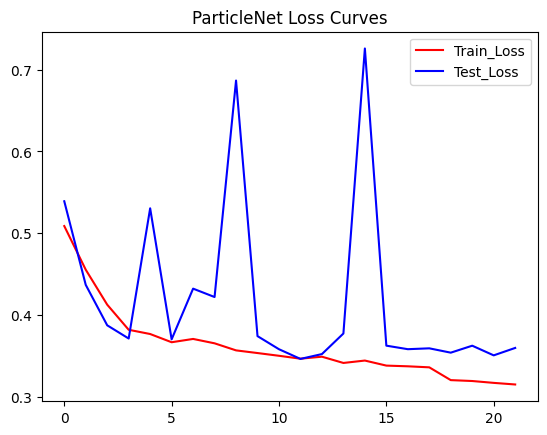

In [16]:
#training model
def train(train_loader, model, optimizer, loss_fn):
    model.train()
    train_loss = 0

    for data in tqdm(train_loader, desc="Training batches"):
        data = data.to(device)
        #print(f"MYDATA: {data}")
        y_pred = model(data)
        #print(y_pred.dtype, label.dtype)
        #[batch, 1, 3] #[batch, 1]
        loss = loss_fn(y_pred, data.label)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

    train_loss /= len(train_loader)
    return train_loss

def test(test_loader, model, loss_fn):
    model.eval()
    test_loss = 0

    with torch.inference_mode():
        for data in test_loader:

            data = data.to(device)

            test_pred = model(data)
            
            #print("TEST_PRED:",test_pred) 
            loss = loss_fn(test_pred, data.label)
            #print("Data_label:", data.label )
            test_loss += loss.item()

    test_loss /= len(test_loader)

    return test_loss
ep = []
result1 = []
result2 = []
best_loss = torch.inf
patience = 10
counter = 0
    
import numpy as np
for epoch in trange (30, desc="Processing"):
    train_loss = train(train_load, model_PN, optimizer_PN, loss)
    test_loss = test( test_load,model_PN, loss)
    ep.append(epoch)
    result1.append(np.array(torch.tensor(train_loss).numpy()))
    result2.append(np.array(torch.tensor(test_loss).numpy()))

    #draw_epoch_graph(G, model_1.latest)
    print(f"Epoch {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}")


    if test_loss < best_loss:

        best_loss = test_loss
        counter = 0
        torch.save({
                "model": model_PN.state_dict(),
                "optimizer": optimizer_PN.state_dict(),
                "scheduler": scheduler_PN.state_dict(),
            }, "checkpoint_PN.pt")
    else:
        counter += 1
    
    if counter==patience:
        print("Stopping")
        break
    
    scheduler_PN.step(test_loss)

print(f"Best for test Loss: {best_loss}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("ParticleNet Loss Curves")
plt.show()

In [17]:

def eval_model(model,valid_loader ):
    model.eval()
    true_preds = num_preds = 0

    with torch.inference_mode():
        for data in valid_loader:
            data = data.to(device)
            Valid_pred = model(data)
            
            pred_labels = torch.argmax(Valid_pred, dim= 1)
            
            true_preds += (pred_labels == data.label).sum()

            num_preds += len(data.label)
    
    acc2 = true_preds/num_preds
    print(f"Accuracy of the model: {100.0*acc2}%")

model_test_PN = ParticleNet(in_feat= len(dataset[0].x[0])).to(device)
checkpoint_PN = torch.load("checkpoint_PN.pt", map_location=device)
model_test_PN.load_state_dict(checkpoint_PN["model"])
optimizer_PN.load_state_dict(checkpoint_PN["optimizer"])
scheduler_PN.load_state_dict(checkpoint_PN["scheduler"])
eval_model(model_test_PN, valid_loader)


Accuracy of the model: 85.79644775390625%


In [18]:
model_PN.eval()

loss1 = test(test_load, model_PN, loss)
loss2 = test(test_load, model_PN, loss)

print(loss1)
print(loss2)

0.3595392512083054
0.359551654279232
